In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

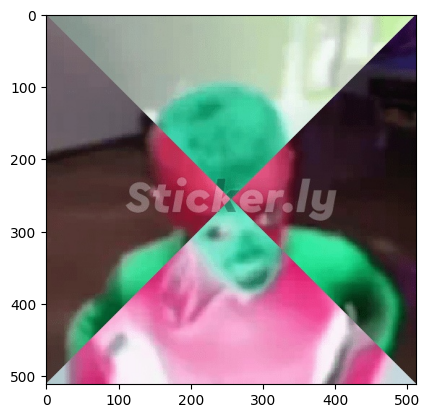

In [2]:
robby = plt.imread("Assets/robby_negatif.jpg")
plt.imshow(robby)

In [14]:
def diagonal_bawah(image):
    height, width = image.shape[:2]
    
    bawah = np.zeros_like(image)
    atas = np.zeros_like(image)

    for i in range(height):
        for j in range(width):
            if i >= j:
                bawah[i, j, :] = image[i, j, :]
            else:
                atas[i, j, :] = image[i, j, :]
                
    return bawah

In [15]:
def diagonal_atas(image):
    height, width = image.shape[:2]
    
    bawah = np.zeros_like(image)
    atas = np.zeros_like(image)

    for i in range(height):
        for j in range(width):
            if i >= j:
                bawah[i, j, :] = image[i, j, :]
            else:
                atas[i, j, :] = image[i, j, :]
                
    return atas

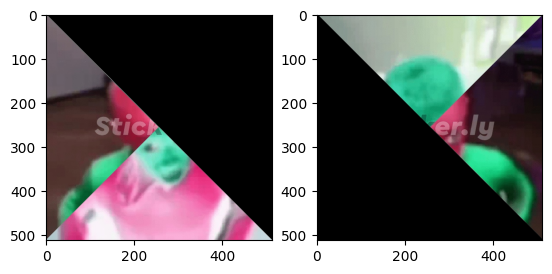

In [17]:
robby_d1 = diagonal_bawah(robby)
robby_d2 = diagonal_atas(robby)

plt.subplot(1,2,1)
plt.imshow(robby_d1)

plt.subplot(1,2,2)
plt.imshow(robby_d2)

In [20]:
def rotasi_rgb(image, derajat):
   
    h, w = image.shape[:2]
    sudut = np.radians(derajat)

    cx, cy = w / 2, h / 2

    
    hasil = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            
            x = (j - cx) * np.cos(-sudut) - (i - cy) * np.sin(-sudut) + cx
            y = (j - cx) * np.sin(-sudut) + (i - cy) * np.cos(-sudut) + cy

            x, y = int(round(x)), int(round(y))

            
            if 0 <= x < w and 0 <= y < h:
        
                hasil[i, j] = image[y, x]

    return hasil

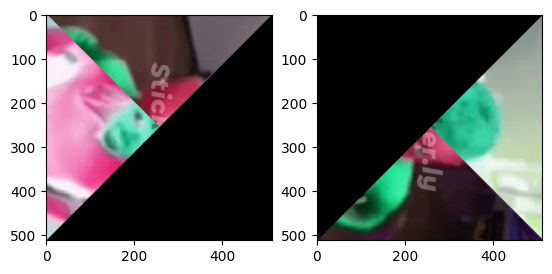

In [22]:
robby_d1_rot = rotasi_rgb(robby_d1, 90)
robby_d2_rot = rotasi_rgb(robby_d2, 90)

plt.subplot(1,2,1)
plt.imshow(robby_d1_rot)
plt.subplot(1,2,2)
plt.imshow(robby_d2_rot)

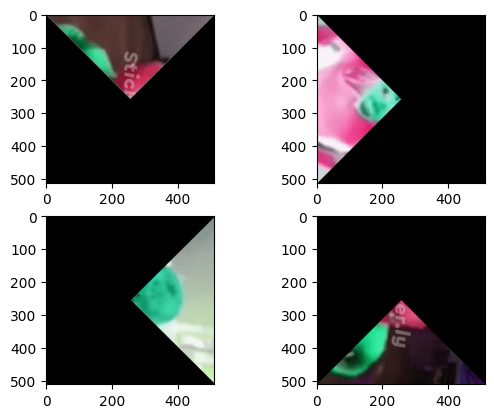

In [35]:
robby_d3 = diagonal_atas(robby_d1_rot)
robby_d4 = diagonal_bawah(robby_d1_rot)
robby_d5 = diagonal_atas(robby_d2_rot)
robby_d6 = diagonal_bawah(robby_d2_rot)

plt.subplot(2,2,1)
plt.imshow(robby_d3)
plt.subplot(2,2,2)
plt.imshow(robby_d4)
plt.subplot(2,2,3)
plt.imshow(robby_d5)
plt.subplot(2,2,4)
plt.imshow(robby_d6)

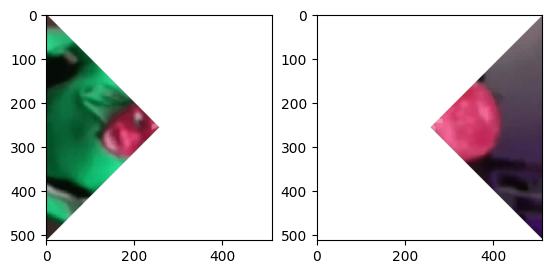

In [36]:
d4_negatif = 255 - robby_d4
d5_negatif = 255 - robby_d5

plt.subplot(1,2,1)
plt.imshow(d4_negatif)
plt.subplot(1,2,2)
plt.imshow(d5_negatif)


In [37]:
def merge_image(citra1, citra2, orientation): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

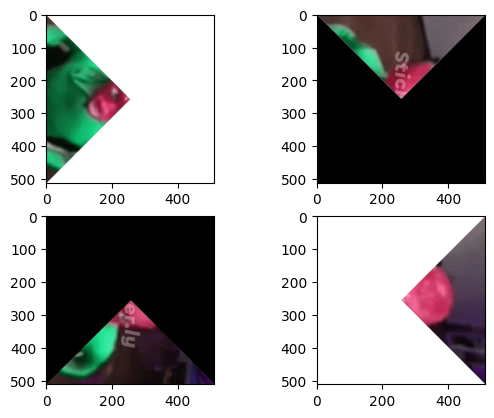

In [38]:
plt.subplot(2,2,1)
plt.imshow(d4_negatif)
plt.subplot(2,2,2)
plt.imshow(robby_d3)
plt.subplot(2,2,3)
plt.imshow(robby_d6)
plt.subplot(2,2,4)
plt.imshow(d5_negatif)

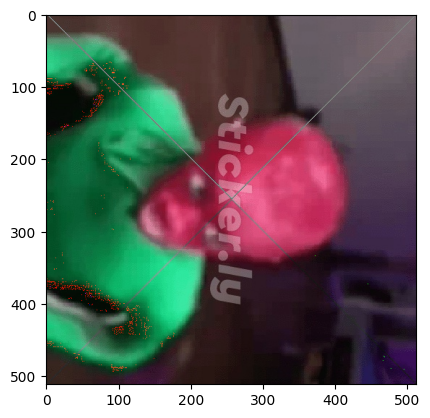

In [39]:
jumlah = d5_negatif + robby_d3 + robby_d6 + d4_negatif
plt.imshow(jumlah)

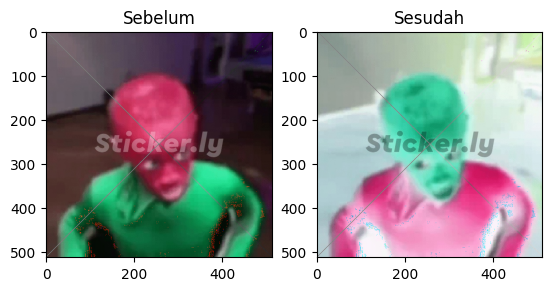

In [44]:
sebelum = rotasi_rgb(jumlah, -90)
sesudah = 255 - sebelum

plt.subplot(1,2,1)
plt.title("Sebelum")
plt.imshow(sebelum)
plt.subplot(1,2,2)
plt.title("Sesudah")
plt.imshow(sesudah)

In [47]:
def normalize_min_max_rgb(image):
    # Mengambil nilai min dan max dari seluruh array (global)
    min_val = np.min(image)
    max_val = np.max(image)
    
    if max_val == min_val:
        return np.zeros_like(image, dtype=np.uint8)
    
    # Konversi ke float agar perhitungan (image - min) tidak error/wrap-around
    # Lalu lakukan normalisasi rumus: (x - min) / (max - min)
    norm = (image.astype(np.float32) - min_val) / (max_val - min_val)
    
    # Kembalikan ke rentang 0-255 dan tipe uint8
    return (norm * 255).astype(np.uint8)

In [51]:
def histogram_equalization_rgb(image):
    # 1. Ambil dimensi (Tinggi, Lebar, Saluran)
    height, width, channels = image.shape
    
    # Siapkan array kosong untuk hasil akhir
    result_image = np.zeros_like(image, dtype=np.uint8)

    # 2. Lakukan iterasi untuk setiap channel (0: Red, 1: Green, 2: Blue)
    for c in range(channels):
        # --- Proses Histogram ---
        hist = np.zeros(256, dtype=int)
        for i in range(height):
            for j in range(width):
                val = image[i, j, c]
                hist[val] += 1

        # --- Proses CDF (Cumulative Distribution Function) ---
        cdf = np.zeros(256, dtype=int)
        cumulative_sum = 0
        for i in range(256):
            cumulative_sum += hist[i]
            cdf[i] = cumulative_sum

        # --- Proses Mapping (Normalisasi CDF ke 0-255) ---
        # Rumus: (cdf(i) * 255) / total_piksel
        lookup_table = np.round((cdf * 255) / (height * width)).astype(np.uint8)

        # --- Terapkan ke Citra ---
        for i in range(height):
            for j in range(width):
                original_val = image[i, j, c]
                result_image[i, j, c] = lookup_table[original_val]

    return result_image

In [54]:
def buat_hist_rgb(citra): 
    # Inisialisasi 3 histogram untuk R, G, dan B
    hist_r = [0] * 256 
    hist_g = [0] * 256 
    hist_b = [0] * 256 
 
    height = citra.shape[0] 
    width = citra.shape[1] 

    for i in range(height): 
        for j in range(width): 
            # Ambil nilai R, G, dan B dari koordinat piksel
            r = int(citra[i, j, 0])
            g = int(citra[i, j, 1])
            b = int(citra[i, j, 2])
            
            hist_r[r] += 1
            hist_g[g] += 1
            hist_b[b] += 1
 
    return hist_r, hist_g, hist_b


def plot_histogram_rgb(hists, title): 
    # hists adalah tuple (hist_r, hist_g, hist_b) dari fungsi sebelumnya
    colors = ('red', 'green', 'blue')
    labels = ('Channel Merah', 'Channel Hijau', 'Channel Biru')
    
    plt.figure(figsize=(10, 6)) 
    
    for i in range(3):
        # Kita gunakan alpha=0.4 agar saat warna bertumpuk, perbedaannya terlihat
        # label=labels[i] penting agar legend bisa muncul otomatis
        plt.bar(range(256), hists[i], color=colors[i], width=1.0, alpha=0.4, label=labels[i])

    plt.title(title) 
    plt.xlabel("Intensitas Piksel (0-255)") 
    plt.ylabel("Jumlah Piksel") 
    
    # Menampilkan keterangan (legend) berdasarkan label yang sudah diset di atas
    plt.legend(loc='upper right') 
    
    plt.grid(axis='y', alpha=0.2)
    plt.show()

# Cara penggunaan:
# h_rgb = buat_hist_rgb(image_rgb)
# plot_histogram_rgb_tumpuk(h_rgb)

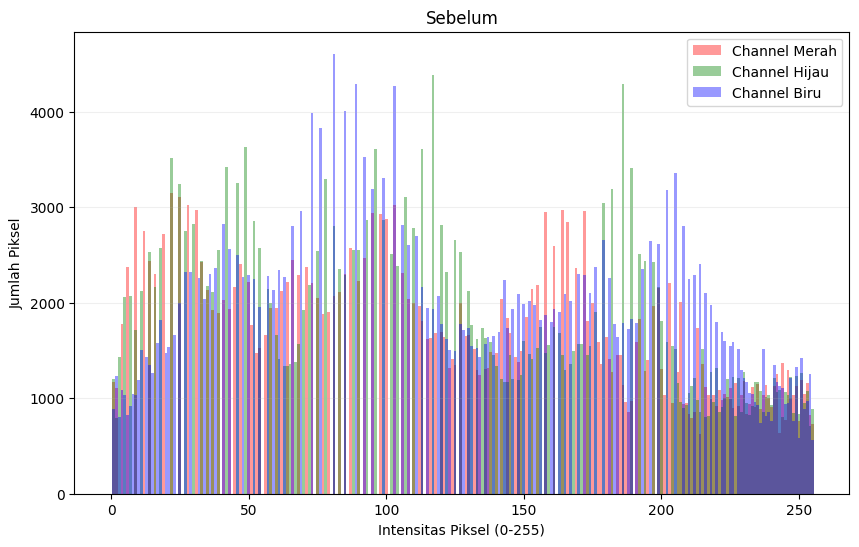

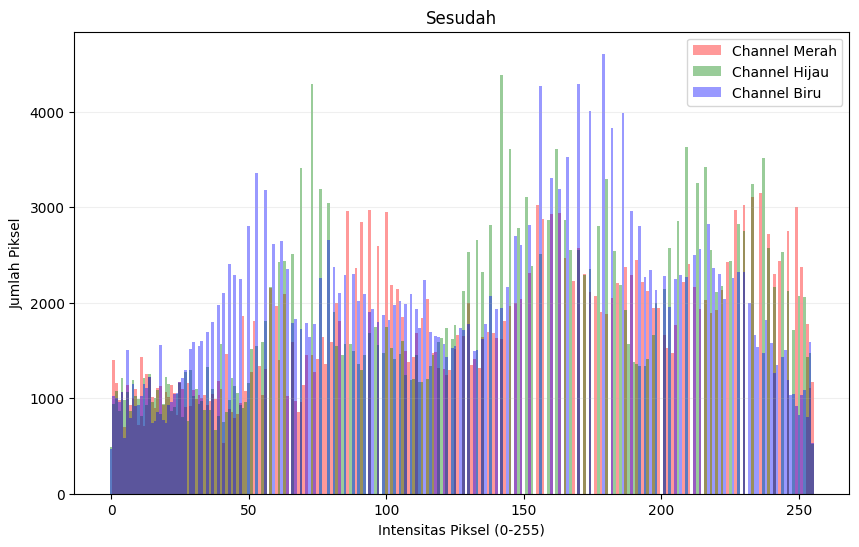

In [55]:
sebelum_norm = normalize_min_max_rgb(sebelum)
sesudah_norm = normalize_min_max_rgb(sesudah)

sebelum_ekual = histogram_equalization_rgb(sebelum_norm)
sesudah_ekual = histogram_equalization_rgb(sesudah_norm)

sebelum_hist = buat_hist_rgb(sebelum_ekual)
sesudah_hist = buat_hist_rgb(sesudah_ekual)

sebelum_plot = plot_histogram_rgb(sebelum_hist, "Sebelum")
sesudah_plot = plot_histogram_rgb(sesudah_hist, "Sesudah")